# Inpatient Readmission Phase 3

> **Builds on:** Phase 2 (`03_readmission_phase2.ipynb`), which established 
> visit-level readmission prediction using temporal features and ensemble models 
> (XGBoost ROC-AUC 0.983, Recall 0.94). Phase 3 adds 8
> chronic condition indicators from the risks dataset (2024_Totals_and _Risk.csv), working on the subset of 
> patients  with overlap between gt_ip and risks (10,046 of 16,991 patients).
> XGBoost improves to ROC-AUC 0.988 and Recall 0.97.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, f1_score
)
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [1]:
gt_ip  = pd.read_csv('ehn-gt-cleaned-inpatient-20251223000.csv')
risks  = pd.read_csv('2024_Totals_and _Risk.csv', low_memory=False)

gt_ip['admitdate']     = pd.to_datetime(gt_ip['admitdate'])
gt_ip['dischargedate'] = pd.to_datetime(gt_ip['dischargedate'])
gt_ip['los_days']      = (gt_ip['dischargedate'] - gt_ip['admitdate']).dt.days.clip(lower=0)

NameError: name 'pd' is not defined

In [3]:
#print(risks.shape)
#print(risks.columns.tolist())

In [4]:
ip_ids   = set(gt_ip['deid_personid'].unique())
risk_ids = set(risks['deid_personid'].unique())
print(f'gt_ip patients     : {len(ip_ids):,}')
print(f'risks patients     : {len(risk_ids):,}')
print(f'overlap            : {len(ip_ids & risk_ids):,}')
print(f'ip not in risks    : {len(ip_ids - risk_ids):,}')


gt_ip patients     : 16,991
risks patients     : 233,925
overlap            : 10,046
ip not in risks    : 6,945


In [5]:
# Dataset Overlap Check
# Verifying that matched and unmatched patients have similar readmission 
# rates before subsetting. Confirms the subset is representative

gt_ip['in_risks'] = gt_ip['deid_personid'].isin(risk_ids).astype(int)

print(gt_ip.groupby('in_risks')['readmission'].agg(['mean', 'count']))

           mean  count
in_risks              
0        0.0725   9769
1        0.0768  14437


Readmission rates are nearly identical between matched (7.7%) and 
unmatched (7.3%) groups. The subset is representative of the 
full inpatient population.

In [6]:
#Dedup from phase 2
gt_ip = (
    gt_ip.sort_values('cost', ascending=False)
    .drop_duplicates(subset=['deid_personid', 'admitdate', 'dischargedate'])
    .sort_values(['deid_personid', 'admitdate'])
    .reset_index(drop=True)
)

In [7]:
# LOS
gt_ip = gt_ip.sort_values(['deid_personid', 'admitdate']).reset_index(drop=True)
gt_ip['n_prior_visits'] = gt_ip.groupby('deid_personid').cumcount()
gt_ip['prev_dischargedate'] = gt_ip.groupby('deid_personid')['dischargedate'].shift(1)
gt_ip['days_since_last_visit'] = (
    (gt_ip['admitdate'] - gt_ip['prev_dischargedate']).dt.days
    ).fillna(-1).clip(lower=-1)

In [8]:
# Pts not in charlson default to 0
charlson = pd.read_csv('charlson_scores.csv')
gt_ip = gt_ip.merge(charlson, on='deid_personid', how='left')
gt_ip['comorbidity_score'] = gt_ip['comorbidity_score'].fillna(0).astype(int)

In [9]:
# risks dataset covers 233k patients but only 10k overlap with gt_ip
# Readmission rates are similar between matched and unmatched groups
# (7.7% vs 7.3%) subset is representative

risk_ids  = set(risks['deid_personid'].unique())
gt_ip_sub = gt_ip[gt_ip['deid_personid'].isin(risk_ids)].copy()

chronic_cols = [
    'deid_personid',
    'chronicconditionasthmaind',
    'chronicconditionesrdind',       # End Stage Renal Disease
    'chronicconditionhfind',         # Heart Failure
    'chronicconditioncrfind',        # Chronic Renal Failure
    'chronicconditionhypertensionind',
    'chronicconditioncancerind',
    'chronicconditioncopdind',
    'chronicconditiondiabetesind',
    'membermonths',
    'counted',
]
risks_sub = risks[chronic_cols].drop_duplicates(subset='deid_personid')
gt_ip_sub = gt_ip_sub.merge(risks_sub, on='deid_personid', how='left')

print(f'Visitas subset : {len(gt_ip_sub):,}')
print(f'Readmission rate: {gt_ip_sub["readmission"].mean():.3f}')

Visitas subset : 14,354
Readmission rate: 0.077


In [10]:
numeric_fts_v2 = [
    'los_days',
    'n_prior_visits',
    'days_since_last_visit',
    'comorbidity_score',
    'membermonths',
    'counted',
    'chronicconditionasthmaind',
    'chronicconditionesrdind',
    'chronicconditionhfind',
    'chronicconditioncrfind',
    'chronicconditionhypertensionind',
    'chronicconditioncancerind',
    'chronicconditioncopdind',
    'chronicconditiondiabetesind',
]

categ_fts_v2 = [
    'planpayer',
    'dischargedisposition',
    'servicing_specialty',
    'icddescription',
]

all_features_v2 = numeric_fts_v2 + categ_fts_v2

X_v2 = gt_ip_sub[all_features_v2].copy()
y_v2 = gt_ip_sub['readmission'].copy()

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size = 0.20,
    random_state = 42,
    stratify = y_v2
)

#print(f'Train: {len(X_train_v2):,} | Test: {len(X_test_v2):,}')
#print(f'Readmission rate — train: {y_train_v2.mean():.3f} | test: {y_test_v2.mean():.3f}')

In [11]:
# --- Preprocessing Pipeline ---
preprocess_v2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categ_fts_v2),
    ('num', 'passthrough', numeric_fts_v2),
])

# --- Model A — Logistic Regression ---
lr_v2 = Pipeline([
    ('prep', preprocess_v2),
    ('clf',  LogisticRegression(max_iter=2000, random_state=42))
])
lr_v2.fit(X_train_v2, y_train_v2)
probs_lr_v2 = lr_v2.predict_proba(X_test_v2)[:, 1]
print('=== Logistic Regression ===')
print(f'ROC-AUC : {roc_auc_score(y_test_v2, probs_lr_v2):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test_v2, probs_lr_v2):.3f}')

# --- Model B — Random Forest ---
rf_v2 = Pipeline([
    ('prep', preprocess_v2),
    ('clf',  RandomForestClassifier(n_estimators = 300, random_state = 42, n_jobs = -1))
])
rf_v2.fit(X_train_v2, y_train_v2)
probs_rf_v2 = rf_v2.predict_proba(X_test_v2)[:, 1]
print('\n=== Random Forest ===')
print(f'ROC-AUC : {roc_auc_score(y_test_v2, probs_rf_v2):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test_v2, probs_rf_v2):.3f}')

# --- Model C — XGBoost ---
xgb_base_v2 = Pipeline([
    ('prep', preprocess_v2),
    ('clf',  XGBClassifier(random_state=42, eval_metric='aucpr', n_jobs=-1))
])
param_grid = {
    'clf__n_estimators'     : [100, 200, 300],
    'clf__max_depth'        : [3, 4, 5, 6],
    'clf__learning_rate'    : [0.01, 0.05, 0.1],
    'clf__subsample'        : [0.7, 0.8, 1.0],
    'clf__scale_pos_weight' : [1, 5, 10],
}
search_v2 = RandomizedSearchCV(
    xgb_base_v2, param_grid,
    n_iter=20, scoring='roc_auc',
    cv=5, random_state=42, n_jobs=-1, verbose=1
)
search_v2.fit(X_train_v2, y_train_v2)
probs_xgb_v2 = search_v2.best_estimator_.predict_proba(X_test_v2)[:, 1]
print('\n=== XGBoost ===')
print(f'Best params : {search_v2.best_params_}')
print(f'ROC-AUC     : {roc_auc_score(y_test_v2, probs_xgb_v2):.3f}')
print(f'PR-AUC      : {average_precision_score(y_test_v2, probs_xgb_v2):.3f}')

=== Logistic Regression ===
ROC-AUC : 0.866
PR-AUC  : 0.430

=== Random Forest ===
ROC-AUC : 0.983
PR-AUC  : 0.857
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/healthcare_2/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== XGBoost ===
Best params : {'clf__subsample': 0.8, 'clf__scale_pos_weight': 1, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.1}
ROC-AUC     : 0.988
PR-AUC      : 0.870


In [12]:
# Optimize threshold 

for name, probs in [
    ('Logistic Regression', probs_lr_v2),
    ('Random Forest',       probs_rf_v2),
    ('XGBoost',             probs_xgb_v2)
]:
    thresholds = np.arange(0.05, 0.95, 0.05)
    scores = [f1_score(y_test_v2, (probs >= t).astype(int), zero_division=0)
              for t in thresholds]
    best_thr = thresholds[np.argmax(scores)]
    print(f'\n{name} — threshold: {best_thr:.2f} | F1: {max(scores):.3f}')
    print(classification_report(y_test_v2, (probs >= best_thr).astype(int), zero_division=0))


Logistic Regression — threshold: 0.15 | F1: 0.488
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2650
           1       0.44      0.55      0.49       221

    accuracy                           0.91      2871
   macro avg       0.70      0.75      0.72      2871
weighted avg       0.92      0.91      0.92      2871


Random Forest — threshold: 0.30 | F1: 0.835
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2650
           1       0.77      0.91      0.83       221

    accuracy                           0.97      2871
   macro avg       0.88      0.95      0.91      2871
weighted avg       0.98      0.97      0.97      2871


XGBoost — threshold: 0.30 | F1: 0.879
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2650
           1       0.80      0.97      0.88       221

    accuracy                           0.98    

## Model Comparison — Phase 1 vs Phase 2 vs Phase 3

| Model | ROC-AUC | PR-AUC | Precision | Recall | F1 | Threshold |
|-------|---------|--------|-----------|--------|----|-----------|
| **Phase 1 — LR (patient level)** | 0.949 | 0.638 | 0.61 | 0.55 | 0.58 | 0.20 |
| **Phase 2 — LR (visit level)** | 0.889 | 0.451 | 0.44 | 0.59 | 0.51 | 0.15 |
| **Phase 2 — Random Forest** | 0.981 | 0.882 | 0.81 | 0.89 | 0.85 | 0.40 |
| **Phase 2 — XGBoost** | 0.983 | 0.860 | 0.78 | 0.94 | 0.86 | 0.65 |
| **Phase 3 — LR (+ chronic conditions)** | 0.866 | 0.430 | 0.44 | 0.55 | 0.49 | 0.15 |
| **Phase 3 — Random Forest (+ chronic conditions)** | 0.983 | 0.857 | 0.77 | 0.91 | 0.83 | 0.30 |
| **Phase 3 — XGBoost (+ chronic conditions)** | 0.988 | 0.870 | 0.80 | 0.97 | 0.88 | 0.30 |

*Phase 1 operates at patient level and not directly comparable to Phase 2/3 (visit level).*

**Results likely overestimate real-world model performance.**

In [13]:
# --- Cross-Validation Phase 3 ---
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [
    ('Logistic Regression', lr_v2),
    ('Random Forest',       rf_v2),
    ('XGBoost',             search_v2.best_estimator_)
]:
    scores = cross_validate(
        model, X_v2, y_v2,
        cv=cv,
        scoring=['roc_auc', 'average_precision'],
        n_jobs=-1
    )
    print(f"\n{name}")
    print(f"ROC-AUC : {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")
    print(f"PR-AUC  : {scores['test_average_precision'].mean():.3f} ± {scores['test_average_precision'].std():.3f}")


Logistic Regression
ROC-AUC : 0.876 ± 0.014
PR-AUC  : 0.431 ± 0.031

Random Forest
ROC-AUC : 0.981 ± 0.004
PR-AUC  : 0.876 ± 0.014

XGBoost
ROC-AUC : 0.988 ± 0.002
PR-AUC  : 0.889 ± 0.013


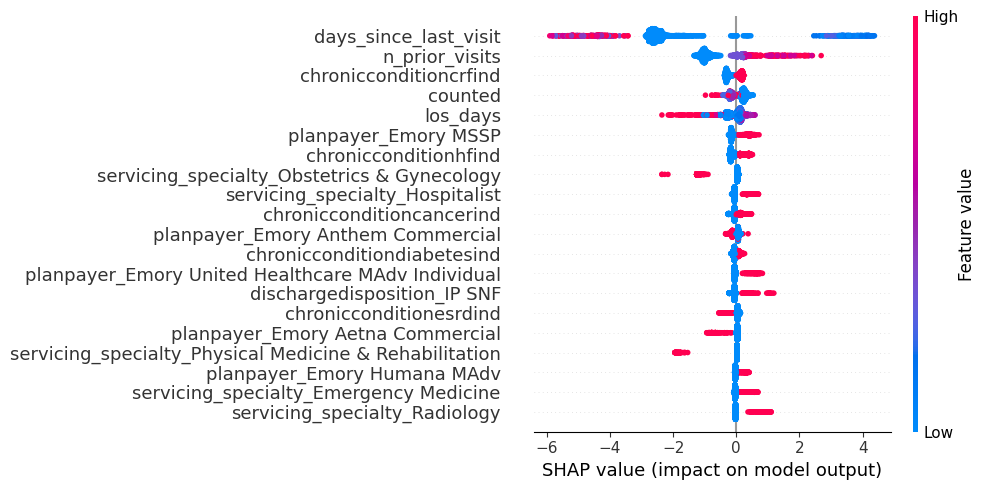

In [14]:
# --- SHAP Phase 3 ---
best_xgb_v2   = search_v2.best_estimator_.named_steps['clf']
preprocessor_v2 = search_v2.best_estimator_.named_steps['prep']

# Get feature names after OHE
cat_feature_names_v2 = (
    preprocessor_v2.named_transformers_['cat']
    .get_feature_names_out(categ_fts_v2)
)
all_feature_names_v2 = np.concatenate([
    cat_feature_names_v2, 
    np.array(numeric_fts_v2)
])

# Transform test set
X_test_transformed_v2 = preprocessor_v2.transform(X_test_v2)

# SHAP
explainer_v2   = shap.TreeExplainer(best_xgb_v2)
shap_values_v2 = explainer_v2.shap_values(X_test_transformed_v2)

shap.summary_plot(
    shap_values_v2,
    X_test_transformed_v2,
    feature_names=all_feature_names_v2,
    max_display=20,
    plot_size=(10, 5)
)

SHAP values show how much each feature pushes the model's prediction 
toward or away from readmission. Red = high feature value, Blue = low.

### Top drivers of readmission risk

**days_since_last_visit** — the most important feature across all phases.
Patients readmitted shortly after discharge are at highest risk.
The longer the gap since the last hospitalization, the lower the risk.

**n_prior_visits** — patients with more hospitalizations in their 
history are more likely to be readmitted. Frequent utilization 
signals underlying clinical instability.

**chronicconditioncrfind (Chronic Renal Failure)** — new in Phase 3. Patients with chronic renal failure show 
significantly elevated readmission risk, consistent with clinical 
literature on high-acuity chronic conditions (Saran *et al*., 2019).

**counted (ED visits)** — number of emergency department visits reflects disease severity or poorly controlled chronic disease.

**los_days** — longer stays are associated with higher readmission risk, 
(likely more severe illness at admission).

### Chronic conditions added in Phase 3
Heart failure (`chronicconditionhfind`), cancer (`chronicconditioncancerind`), 
diabetes (`chronicconditiondiabetesind`), and end stage renal disease ESRD (`chronicconditionesrdind`) 
all appear in the top 20 features. Condition-level 
granularity adds signal beyond the Charlson composite score.

### Low-risk signal
Obstetrics & Gynecology encounters reduce predicted risk 
(reflects planned maternity admissions which are typically short-term)

### Key takeaway
Temporal features (`days_since_last_visit`, `n_prior_visits`) remain 
the strongest predictors across all phases. The addition of chronic 
condition indicators in Phase 3 pushed recall from 0.94 to 0.97, 
capturing an additional 3% of actual readmissions that Phase 2 missed.


### SHAP Phase 2 
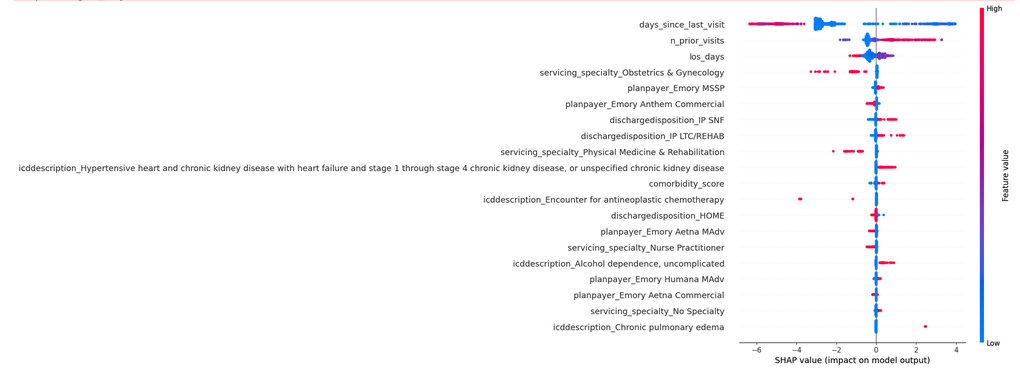

## Results Summary — Phase 3

### Dataset
- **Visits:** 14,354 (subset with risks overlap)
- **Readmission rate:** 7.7% — consistent with full dataset (7.5%)
- **New features added:** 8 chronic condition indicators + membermonths + ED visits

### Why subset?
Only 59% of inpatient patients (10,046 / 16,991) appear in the risks 
dataset. Readmission rates between matched (7.7%) and unmatched (7.3%) 
groups are nearly identical, confirming the subset is representative.

### Model Performance (optimized threshold)

| Model | ROC-AUC | PR-AUC | Precision | Recall | F1 | Threshold |
|-------|---------|--------|-----------|--------|----|-----------|
| Logistic Regression | 0.866 | 0.430 | 0.44 | 0.55 | 0.49 | 0.15 |
| Random Forest | 0.983 | 0.857 | 0.77 | 0.91 | 0.83 | 0.30 |
| **XGBoost** | **0.988** | **0.870** | **0.80** | **0.97** | **0.88** | **0.30** |

### Cross-Validation (5-fold)

| Model | ROC-AUC | PR-AUC |
|-------|---------|--------|
| Logistic Regression | 0.876 ± 0.014 | 0.431 ± 0.031 |
| Random Forest | 0.981 ± 0.004 | 0.876 ± 0.014 |
| XGBoost | 0.988 ± 0.002 | 0.889 ± 0.013 |

Results are stable across folds and no overfitting wasdetected.

### Phase 2 vs Phase 3 XGBoost

| Metric | Phase 2 | Phase 3 | Δ |
|--------|---------|---------|---|
| ROC-AUC | 0.983 | 0.988 | +0.005 |
| PR-AUC | 0.860 | 0.870 | +0.010 |
| Recall | 0.94 | 0.97 | +0.03 |
| F1 | 0.86 | 0.88 | +0.02 |

### Key finding
Chronic condition indicators added meaningful signal beyond the Charlson composite score (particularly chronic renal failure 
(`chronicconditioncrfind`) and heart failure (`chronicconditionhfind`)), pushing 
recall from 0.94 to 0.97 and capturing an additional 3% of actual 
readmissions.

### For report

*Caveats on Model Performance*

The high ROC-AUC scores (0.983–0.988) warrant careful interpretation.

**Potential structural correlation**
The readmission label was derived from the same inpatient dataset 
used to engineer temporal features (days_since_last_visit, n_prior_visits). 
This creates a structural relationship between features and label 
that may inflate performance metrics beyond what would be observed 
in a true prospective deployment.

### Limitations
- We only have a single year of data available
- No external validation cohort
- SHAP explains the model, but does not show causality

*Random split limitation* — Models were evaluated using a random 80/20 
split rather than a temporal split, which likely overestimates real-world 
performance. Ideally, the model would be trained on historical data and 
scored on future admissions. We recommend the sponsor provide additional 
historical data to enable temporal validation and a more realistic 
performance estimate.

**Results likely overestimate real-world model performance.**


## References

> Saran, R., Robinson, B., Abbott, K. C., et al. (2019). US Renal Data System 
> 2019 Annual Data Report: Epidemiology of Kidney Disease in the United States. 
> *American Journal of Kidney Diseases, 75*(1 Suppl 1), A6–A7. 
> https://doi.org/10.1053/j.ajkd.2019.09.003

## Idea for outpatient dataset

- [ ] Add data from gt_op 
      (`n_op_visits`, `n_unique_op_dx`, etc. Consider that many ambulatory visits before an inpatient encounter may suggest a bad controlled chronic condition, and many op diagnoses count could indicate a complex case, so + risk and + cost)